In [ ]:
pip install your_library_name

In [ ]:
pip install your_library_name

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
import os
os.listdir("/content/drive/MyDrive")

['Colab Notebooks',
 'Niveditha cohort10',
 'Screenshot_20250329_110542.jpg',
 '4SN23EC033_NIVEDITHA TD_PALOHALT_16 03 2025.pdf',
 'IMG_20250412_141821.jpg',
 'Document from Niveditha Devegowda',
 'Document from Niveditha Devegowda (1).pdf',
 'Document from Niveditha Devegowda.pdf',
 'Gripper Assembly 3.STL',
 'project.ipynb',
 'Untitled0.ipynb',
 'project1.ipynb',
 'project2.ipynb',
 'Screw Driver',
 'Resume ',
 '1769349967 - 450.00 To 4960 on Google Pay.png',
 'dataset',
 'tool_classifier_model.h5',
 'class_names.json',
 'final_dataset',
 'tools_classifier_model.h5',
 'cutter',
 'Untitled1.ipynb',
 'wire_cutter_dataset',
 'wire_cutter',
 'blade (1)',
 'blade',
 'screw_driver',
 'screwdriver',
 'mock.pdf',
 'IMG-20260325-WA0000.jpg',
 'trained_dataset.h5']

In [ ]:
import os
os.listdir("/content/drive/MyDrive/final_dataset")

['train_dataset']

In [ ]:
import os
os.listdir("/content/drive/MyDrive/final_dataset/train_dataset")

['blade', 'cutter', 'screwdriver', 'spanner']

In [ ]:
data_dir = "/content/drive/MyDrive/final_dataset/train_dataset"

In [ ]:
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 880 files belonging to 4 classes.
Using 704 files for training.
Found 880 files belonging to 4 classes.
Using 176 files for validation.


In [ ]:
print(train_ds.class_names)

['blade', 'cutter', 'screwdriver', 'spanner']


In [ ]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
from tensorflow.keras import models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')  # 4 tools
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.4375 - loss: 151.4954 - val_accuracy: 0.5568 - val_loss: 1.2446
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.6761 - loss: 0.8844 - val_accuracy: 0.6534 - val_loss: 1.0809
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.8253 - loss: 0.4406 - val_accuracy: 0.7102 - val_loss: 1.3675
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 100s 5s/step - accuracy: 0.9162 - loss: 0.2499 - val_accuracy: 0.7727 - val_loss: 1.6135
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.9418 - loss: 0.2398 - val_accuracy: 0.7500 - val_loss: 1.5262
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.9574 - loss: 0.1754 - val_accuracy: 0.7955 - val_loss: 1.8009
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 138s 4s/step - accuracy: 0.9645 - loss: 0.1579 - val_accuracy: 0.6591 - val_loss: 2.6266
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.9318 - loss: 0.3507 - val_accuracy: 0.7386 - val_

In [ ]:
import os
from PIL import Image

data_dir = "/content/drive/MyDrive/final_dataset/train_dataset"

bad_files = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            file_path = os.path.join(class_path, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                bad_files.append(file_path)
                os.remove(file_path)

print("Removed files:")
for f in bad_files:
    print(f)

Removed files:


In [ ]:
import os
from PIL import Image

def clean_folder(folder):
    removed = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Removing:", path)
                os.remove(path)
                removed += 1
    print("Total removed:", removed)

train_path = "/content/drive/MyDrive/final_dataset/train_dataset"
val_path   = "/content/drive/MyDrive/final_dataset/val_data"

clean_folder(train_path)
clean_folder(val_path)

Total removed: 0
Total removed: 0


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 880 files belonging to 4 classes.
Using 704 files for training.
Found 880 files belonging to 4 classes.
Using 176 files for validation.


In [ ]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
import os
import tensorflow as tf

def clean_folder_tf_check(folder_path):
    removed_count = 0
    # List all files first to avoid issues with os.walk changing directory contents during iteration
    files_to_check = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            files_to_check.append(os.path.join(root, file))

    for file_path in files_to_check:
        # Only process known image extensions to avoid trying to decode non-image files
        if file_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            try:
                img_bytes = tf.io.read_file(file_path)
                # Try to decode the image. If it fails, it's a bad file for TF.
                # channels=3 for RGB images, expand_animations=False for static images
                _ = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
            except (tf.errors.InvalidArgumentError, tf.errors.OutOfRangeError) as e:
                print(f"Removing problematic file: {file_path} (Error: {e})")
                os.remove(file_path)
                removed_count += 1
            except Exception as e:
                # Catch other potential errors during reading/decoding
                print(f"An unexpected error occurred with {file_path}: {e}. Removing file.")
                os.remove(file_path)
                removed_count += 1
    print(f"Total files removed from {folder_path} after TensorFlow verification: {removed_count}")
    return removed_count

# Clean the dataset directory using the TensorFlow-based check
clean_folder_tf_check(data_dir)

# Recreate train_ds and val_ds after cleaning
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Apply normalization layer to the recreated datasets
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Compile the model before retraining
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Retrain the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Total files removed from /content/drive/MyDrive/final_dataset/train_dataset after TensorFlow verification: 0
Found 880 files belonging to 4 classes.
Using 704 files for training.
Found 880 files belonging to 4 classes.
Using 176 files for validation.
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 111s 5s/step - accuracy: 0.4347 - loss: 1.4755 - val_accuracy: 0.5852 - val_loss: 1.1105
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 97s 4s/step - accuracy: 0.6207 - loss: 0.9292 - val_accuracy: 0.6761 - val_loss: 0.9248
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 97s 4s/step - accuracy: 0.7557 - loss: 0.6170 - val_accuracy: 0.6989 - val_loss: 0.8100
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.8935 - loss: 0.3426 - val_accuracy: 0.7784 - val_loss: 0.8078
Epoch 5/10
18/22 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.9525 - loss: 0.1819

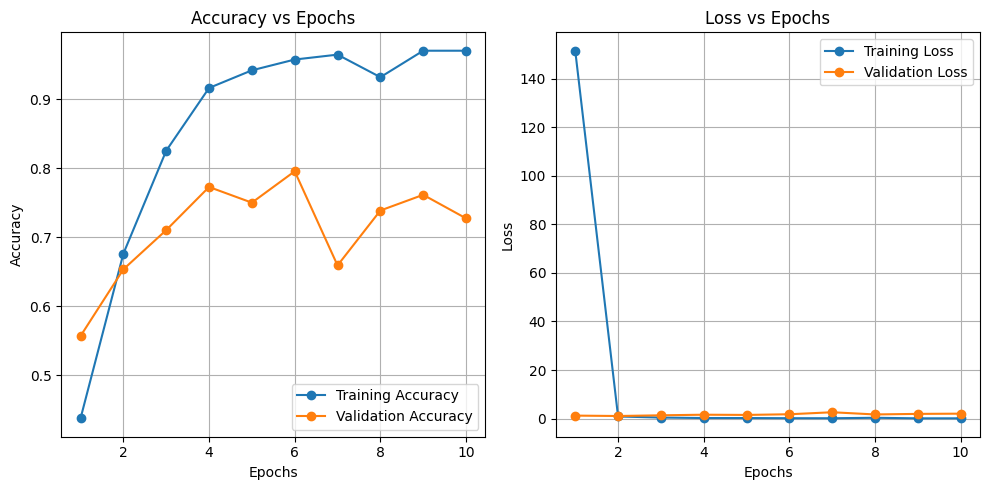

In [ ]:
import matplotlib.pyplot as plt

# Extract values from history
acc = history.history.get('accuracy')
val_acc = history.history.get('val_accuracy')
loss = history.history.get('loss')
val_loss = history.history.get('val_loss')

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10,5))

# 🔹 Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, marker='o', label='Training Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# 🔹 Loss Graph
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/trained_dataset.h5")

In [ ]:
import numpy as np
import tensorflow as tf # Required for image utilities
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image


model_path = "/content/drive/MyDrive/trained_dataset.h5"
try:
    model = load_model(model_path)
    print(f"Model loaded successfully from {model_path}")
except Exception as e:
    print(f"Error loading model from {model_path}: {e}")


img_size = (224, 224) # As defined in earlier cells (e.g., wO2YsRjkXs2M)
class_names = ['blade', 'cutter', 'screwdriver', 'spanner'] # As output in cell gXlxKz1FYoZC


sample_image_path = "/content/drive/MyDrive/final_dataset/train_dataset/blade/blade (1).jpg"

try:
    img = image.load_img(sample_image_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Convert single image to a batch of size 1.
    img_array = img_array / 255.0  # Normalize to [0, 1] as done during training.

    # 4. Make a prediction to define 'pred'
    pred = model.predict(img_array)

    # --- Original code from the selected cell, now executable ---
    predicted_index = np.argmax(pred)
    print("Predicted class:", class_names[predicted_index])

except FileNotFoundError:
    print(f"Error: Sample image not found at {sample_image_path}. Please verify the path.")
except NameError as e:
    print(f"Error: {e}. Ensure 'model' and 'class_names' are properly defined.")
except Exception as e:
    print(f"An unexpected error occurred during prediction: {e}")

Model loaded successfully from /content/drive/MyDrive/trained_dataset.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Predicted class: spanner


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/trained_dataset.h5")

In [ ]:
confidence = np.max(pred) * 100
print(f"Confidence: {confidence:.2f}%")

Confidence: 27.92%


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cutter (1).jpg to cutter (1).jpg


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

print("Predicted class:", class_names[np.argmax(pred)])
print("Confidence:", np.max(pred)*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Predicted class: cutter
Confidence: 99.999916


In [ ]:
model = load_model("/content/drive/MyDrive/trained_dataset.h5")

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# load model
model = load_model("/content/drive/MyDrive/trained_dataset.h5")

# class names (CHANGE according to your dataset folders)
class_names = ["blade", "cutter", "screwdriver", "spanner"]

def predict_image(img):
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    index = np.argmax(preds)

    return {
        class_names[i]: float(preds[i])
        for i in range(len(class_names))
    }

demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="Image Classification Model",
    description="Upload an image to test the trained model",
    theme="soft"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2251a17b66f203cb90.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip uninstall -y gradio
!pip install gradio

Found existing installation: gradio 6.6.0
Uninstalling gradio-6.6.0:
  Successfully uninstalled gradio-6.6.0
  Using cached gradio-6.6.0-py3-none-any.whl.metadata (16 kB)
Using cached gradio-6.6.0-py3-none-any.whl (24.2 MB)


In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# load model
model = tf.keras.models.load_model("/content/drive/MyDrive/trained_dataset.h5")

# class names (CHANGE according to your dataset folders)
class_names = ["blade", "cutter", "screwdriver", "spanner"]

def predict_image(img):
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    index = np.argmax(preds)

    return {
        class_names[i]: float(preds[i])
        for i in range(len(class_names))
    }

demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="Image Classification Model",
    description="Upload an image to test the trained model",
    theme="soft"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a882c12a6670f1d5df.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/trained_dataset.h5")

In [ ]:
model = tf.keras.models.load_model("/content/drive/MyDrive/trained_dataset.h5")

In [ ]:
import tensorflow as tf
import gradio as gr
import numpy as np
from PIL import Image

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/trained_dataset.h5"
)

In [ ]:
class_names = ["blade", "cutter", "screwdriver", "spanner"]
# 👆 example — replace with YOUR classes

In [ ]:
def predict_image(img):
    img = img.resize((224, 224))   # change size if you trained different
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img)[0]

    return {class_names[i]: float(preds[i]) for i in range(len(class_names))}

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# Load the model
model = tf.keras.models.load_model("/content/drive/MyDrive/trained_dataset.h5")

# Define class names
class_names = ["blade", "cutter", "screwdriver", "spanner"]

def predict_image(img):
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]

    return {class_names[i]: float(preds[i]) for i in range(len(class_names))}

demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="📤 Upload Tool Image"),
    outputs=gr.Label(num_top_classes=3, label="🔍 Prediction"),
    title="🔧 Tool Classification Model",
    description="Upload an image to test the trained ML model",
    theme="soft"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f7b1c73fe5456d87c4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
model.save("model.h5")